Dataset loaded successfully!
Available variables: ['time_bnds', 'lat_bnds', 'lon_bnds', 'depth_bnds', 'mrsos', 'tas', 'hfls']
Time range: 2020-12-01 12:00:00 to 2050-11-30 12:00:00
Original latitude range: -90.0°N to 90.0°N

CREATING NATURE PAPER QUALITY TEMPERATURE PLOT FOR DJF
WITH SEASONAL MEAN AGGREGATION (23.5-35°N)
DJF = December (previous year) + January + February
Creating combined temperature plot for Northern Subtropics (23.5°N-35°N)
Season: DJF, Temperature bins: 5
Stratification method: temperature_thresholds
Confidence ellipses: 1σ (68%) and 2σ (95.4%)
Using Nature paper quality distinguished colors
**USING SEASONAL MEAN AGGREGATION**
**DJF: December from previous year, JF from current year**

Step 1: Extracting data...
Step 1.5: Filtering for Northern Subtropics (23.5°N to 35°N)...
   Latitude range: 35.3°N to 59.8°N

Step 2: Spatial aggregation...
Converting temperature from Kelvin to Celsius...
Converting evaporation to mm/day...
Converting soil moisture...

Step 3: App

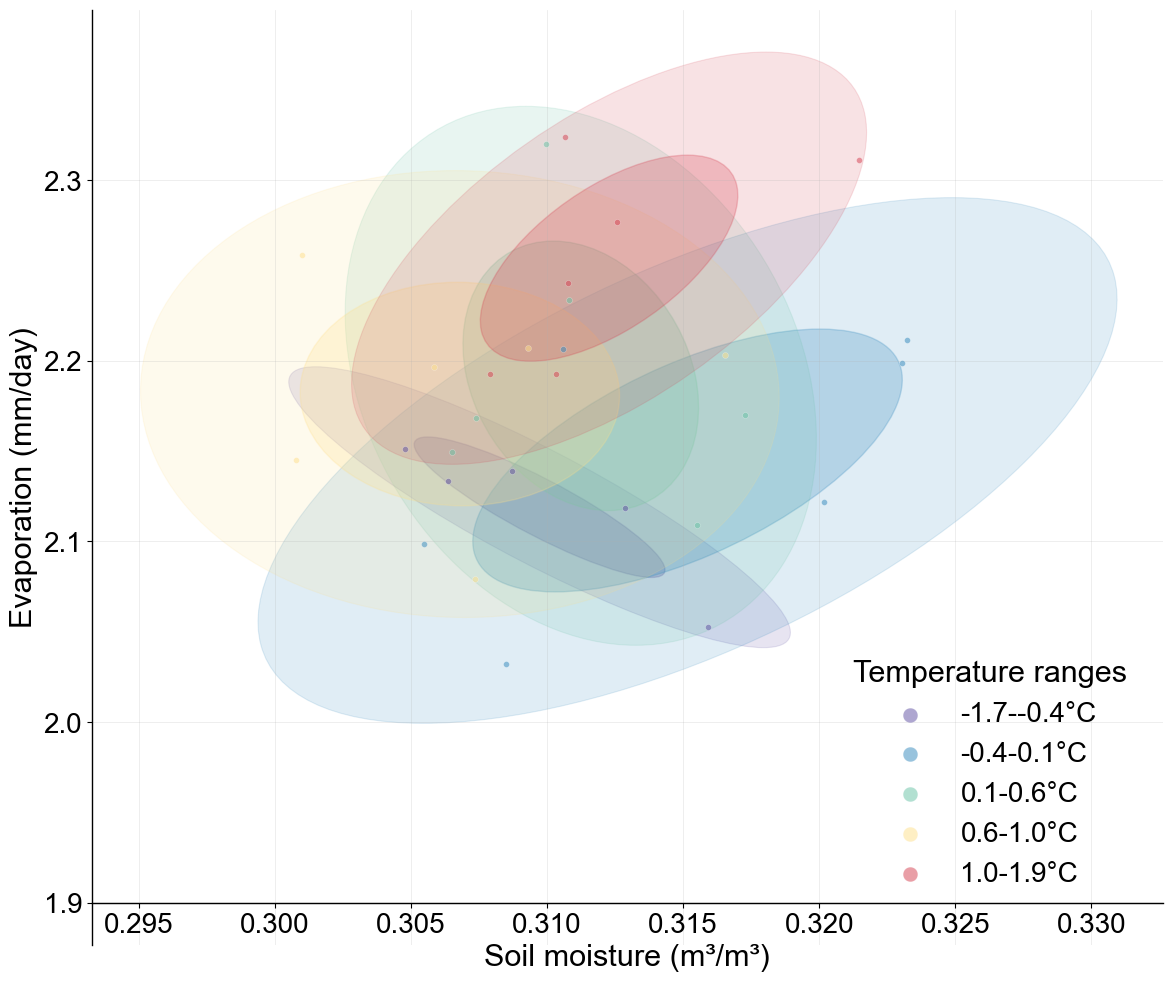


✅ Nature paper quality plot saved as 'SM-E_contour_DJF.png'


In [35]:
# Climate Conditional Plot - Single Plot with Multiple Temperature Bins
# Shows how Soil Moisture - Evaporation relationship changes with increasing temperature
# Modified for DJF season with 1σ and 2σ confidence ellipses
# Uses temperature_thresholds stratification method - All bins in one plot
# Nature paper quality with distinguished colors
# MODIFIED: Added seasonal mean aggregation and consistent 23.5-35°N latitude bands
# MODIFIED: Simplified legend to show only temperature ranges
# MODIFIED: DJF season handling - December from previous year, JF from current year
# To change the region, change    # Step 1.5: Filter for Northern Subtropics (23.5°N to 35°N)
   # print("Step 1.5: Filtering for Northern Subtropics (23.5°N to 35°N)...")
   # lat_min, lat_max = 35.0, 60.0

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

# Set professional climate science style for Nature paper
plt.rcParams.update({
    'font.family': 'Arial',
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'figure.titlesize': 12,
    'lines.linewidth': 1.2,
    'axes.linewidth': 1.0,
})

def add_confidence_ellipse(ax, x, y, color, alpha=0.2, n_std=1.0, linewidth=0.8):
    """Add confidence ellipse around data points using eigenvalue decomposition
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to add ellipse to
    x, y : array-like
        Data points
    color : color specification
        Color for the ellipse
    alpha : float
        Transparency of ellipse
    n_std : float
        Number of standard deviations (1.0 for 1σ, 2.0 for 2σ, etc.)
    linewidth : float
        Width of ellipse border
    """
    if len(x) < 3:
        return None
    
    # Calculate covariance matrix
    cov = np.cov(x, y)
    
    # Get eigenvalues and eigenvectors
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    
    # Calculate ellipse parameters
    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    width = 2 * n_std * np.sqrt(eigenvals[0])
    height = 2 * n_std * np.sqrt(eigenvals[1])
    
    # Create ellipse
    ellipse = patches.Ellipse(xy=(np.mean(x), np.mean(y)),
                              width=width, height=height,
                              angle=angle, alpha=alpha,
                              facecolor=color, edgecolor=color,
                              linewidth=linewidth)
    ax.add_patch(ellipse)
    return ellipse

def create_temperature_stratification(df, n_bins=5, method='temperature_thresholds'):
    """
    Create temperature bins for conditional analysis during Northern Subtropics DJF season
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with temperature data
    n_bins : int
        Number of temperature bins
    method : str
        'quantile', 'equal_width', or 'temperature_thresholds'
        
    Returns:
    --------
    df : pandas.DataFrame with 'temp_bin' column added
    temperature_bins : dict mapping bin_id to (low_temp, high_temp) tuple
    """
    
    if method == 'quantile':
        df['temp_bin'] = pd.qcut(df['temperature'], n_bins, labels=False, duplicates='drop')
        bin_edges = pd.qcut(df['temperature'], n_bins, retbins=True, duplicates='drop')[1]
    elif method == 'equal_width':
        df['temp_bin'] = pd.cut(df['temperature'], n_bins, labels=False)
        bin_edges = pd.cut(df['temperature'], n_bins, retbins=True)[1]
    elif method == 'temperature_thresholds':
        # Northern Subtropics DJF-specific temperature thresholds
        temp_percentiles = np.percentile(df['temperature'], [20, 40, 60, 80])
        bin_edges = np.concatenate([[df['temperature'].min()], 
                                  temp_percentiles, 
                                  [df['temperature'].max()]])
        df['temp_bin'] = pd.cut(df['temperature'], bin_edges, labels=False)
    
    # Get actual number of bins created
    actual_n_bins = df['temp_bin'].nunique()
    
    temperature_bins = {
        i: (bin_edges[i], bin_edges[i+1]) 
        for i in range(actual_n_bins)
    }
    
    print("\nNorthern Subtropics DJF Temperature stratification:")
    for i, (low, high) in temperature_bins.items():
        n_obs = (df['temp_bin'] == i).sum()
        # Add interpretation labels for Northern Subtropics DJF temperatures
        if high < np.percentile(df['temperature'], 25):
            label = "Cool Northern Subtropics DJF"
        elif low > np.percentile(df['temperature'], 75):
            label = "Hot Northern Subtropics DJF"
        else:
            label = "Moderate Northern Subtropics DJF"
        print(f"Bin {i}: {low:.2f}°C to {high:.2f}°C ({label}, {n_obs} observations)")
    
    return df, temperature_bins

def get_nature_colors(n_bins):
    """
    Get distinguished colors suitable for Nature paper
    Returns colors that are visually distinct and colorblind-friendly
    Progressive color scheme from cool to hot temperatures
    """
    if n_bins == 5:
        # Alternative option 2 - Purple to red spectrum
        colors = [
            '#5E4FA2',  # Cool: Purple
            '#3288BD',  # Cool-Moderate: Blue
            '#66C2A5',  # Moderate: Teal
            '#FEE08B',  # Moderate-Hot: Yellow
            '#D53E4F',  # Hot: Red
        ]
        
    elif n_bins == 4:
        colors = [
            '#3288BD',  # Cool: Ocean blue
            '#66C2A5',  # Moderate-Cool: Teal
            '#FDAE61',  # Moderate-Hot: Orange
            '#D53E4F',  # Hot: Crimson red
        ]
        
    elif n_bins == 3:
        colors = [
            '#3288BD',  # Cool: Ocean blue
            '#ABDDA4',  # Moderate: Light green
            '#D53E4F',  # Hot: Crimson red
        ]
        
    else:
        # Fallback to colormap for other bin numbers
        colors = plt.cm.Spectral_r(np.linspace(0.15, 0.85, n_bins))
    
    return colors

def create_combined_temperature_plot(dataset, n_temp_bins=5, stratification_method='temperature_thresholds',
                                    temp_var='tas', evaporation_var='hfls', sm_var='mrsos',
                                    season='DJF', figsize=(12, 10),
                                    add_ellipse=True, ellipse_alpha_outer=0.15, ellipse_alpha_inner=0.25):
    """
    Create single plot showing how SM-E relationship changes across temperature range
    All temperature bins overlaid with different colors
    Focused on Northern Subtropics (23.5°N to 35°N)
    Shows 1σ (68%) and 2σ (95.4%) confidence ellipses
    Nature paper quality with distinguished colors
    **MODIFIED: Uses seasonal mean aggregation**
    **MODIFIED: DJF season - December from previous year, JF from current year**
    **MODIFIED: Simplified legend to show only temperature ranges**
    
    Parameters:
    -----------
    dataset : xarray.Dataset
        Climate data containing soil moisture, evaporation, and temperature
    n_temp_bins : int
        Number of temperature bins to create (default: 5)
    stratification_method : str
        Temperature binning method: 'quantile', 'equal_width', or 'temperature_thresholds'
    temp_var : str
        Temperature variable name in dataset
    evaporation_var : str  
        Evaporation variable name in dataset
    sm_var : str
        Soil moisture variable name in dataset
    season : str
        Season to analyze ('JJA', 'DJF', 'MAM', 'SON')
    figsize : tuple
        Figure size (width, height)
    add_ellipse : bool
        Whether to add confidence ellipse around data points
    ellipse_alpha_outer : float
        Transparency of outer (2σ) confidence ellipse
    ellipse_alpha_inner : float
        Transparency of inner (1σ) confidence ellipse
        
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    
    print(f"Creating combined temperature plot for Northern Subtropics (23.5°N-35°N)")
    print(f"Season: {season}, Temperature bins: {n_temp_bins}")
    print(f"Stratification method: {stratification_method}")
    print(f"Confidence ellipses: 1σ (68%) and 2σ (95.4%)")
    print(f"Using Nature paper quality distinguished colors")
    print(f"**USING SEASONAL MEAN AGGREGATION**")
    print(f"**DJF: December from previous year, JF from current year**")
    
    # Step 1: Extract and preprocess data
    print("\nStep 1: Extracting data...")
    
    # Extract variables
    sm = dataset[sm_var]
    temp = dataset[temp_var]
    evaporation = dataset[evaporation_var]
    
    # Step 1.5: Filter for Northern Subtropics (23.5°N to 35°N)
    print("Step 1.5: Filtering for Northern Subtropics (23.5°N to 35°N)...")
    lat_min, lat_max = 35.0, 60.0
    
    if 'lat' in dataset.coords:
        lat_mask = (dataset.lat >= lat_min) & (dataset.lat <= lat_max)
        sm = sm.where(lat_mask, drop=True)
        temp = temp.where(lat_mask, drop=True)
        evaporation = evaporation.where(lat_mask, drop=True)
        print(f"   Latitude range: {sm.lat.min().values:.1f}°N to {sm.lat.max().values:.1f}°N")
    
    # Step 2: Spatial aggregation (weighted by latitude) BEFORE seasonal filtering
    print("\nStep 2: Spatial aggregation...")
    weights = np.cos(np.deg2rad(sm.lat))
    weights.name = "weights"
    
    sm_agg = sm.weighted(weights).mean(dim=['lat', 'lon'])
    temp_agg = temp.weighted(weights).mean(dim=['lat', 'lon'])  
    evaporation_agg = evaporation.weighted(weights).mean(dim=['lat', 'lon'])
    
    # Convert temperature from Kelvin to Celsius if needed
    if temp_agg.max() > 100:
        print("Converting temperature from Kelvin to Celsius...")
        temp_agg = temp_agg - 273.15
    
    # Convert evaporation to mm/day
    print("Converting evaporation to mm/day...")
    evaporation_agg = evaporation_agg * 86400 / (2.45e6)
    
    # Convert soil moisture
    print("Converting soil moisture...")
    sm_agg = sm_agg / (1000 * 0.1)
    
    # Step 3: DJF seasonal mean aggregation
    print("\nStep 3: Applying DJF seasonal mean aggregation...")
    print("   DJF = December (year-1) + January + February (year)")
    
    # Create time dataframe
    time_df = pd.DataFrame({
        'year': sm_agg.time.dt.year.values,
        'month': sm_agg.time.dt.month.values,
        'time_index': range(len(sm_agg.time))
    })
    
    # Group by DJF winter season (December of previous year + JF of current year)
    djf_years = []
    sm_seasonal_list = []
    temp_seasonal_list = []
    evaporation_seasonal_list = []
    
    for year in sorted(time_df['year'].unique()):
        # Get December from previous year
        dec_prev = time_df[(time_df['year'] == year - 1) & (time_df['month'] == 12)]
        # Get January and February from current year
        jan_feb = time_df[(time_df['year'] == year) & (time_df['month'].isin([1, 2]))]
        
        # Combine indices
        djf_indices = list(dec_prev['time_index']) + list(jan_feb['time_index'])
        
        if len(djf_indices) >= 2:  # Need at least 2 months for a proper DJF season
            sm_val = float(sm_agg.isel(time=djf_indices).mean().values)
            temp_val = float(temp_agg.isel(time=djf_indices).mean().values)
            evaporation_val = float(evaporation_agg.isel(time=djf_indices).mean().values)
            
            sm_seasonal_list.append(sm_val)
            temp_seasonal_list.append(temp_val)
            evaporation_seasonal_list.append(evaporation_val)
            djf_years.append(year)
    
    # Create DataFrame with seasonal means
    df = pd.DataFrame({
        'soil_moisture': sm_seasonal_list,
        'temperature': temp_seasonal_list,
        'evaporation': evaporation_seasonal_list,
        'djf_year': djf_years
    }).dropna()
    
    print(f"\nTotal DJF seasons: {len(df):,}")
    print(f"Year range: {df.djf_year.min()} to {df.djf_year.max()}")
    print(f"Temperature range: {df.temperature.min():.1f}°C to {df.temperature.max():.1f}°C")
    print(f"Evaporation range: {df.evaporation.min():.3f} to {df.evaporation.max():.3f} mm/day")
    print(f"Soil moisture range: {df.soil_moisture.min():.3f} to {df.soil_moisture.max():.3f} m³/m³")
    
    # Step 4: Create temperature stratification using specified method
    print(f"\nStep 4: Creating temperature stratification using '{stratification_method}' method...")
    df, temperature_bins = create_temperature_stratification(df, n_bins=n_temp_bins, method=stratification_method)
    
    actual_n_bins = len(temperature_bins)
    
    # Step 5: Create single plot with all temperature bins
    print(f"\nStep 5: Creating combined plot with {actual_n_bins} temperature bins...")
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get distinguished colors for Nature paper
    colors = get_nature_colors(actual_n_bins)
    print(f"   Using {actual_n_bins} distinguished colors for Nature paper quality")
    
    # Plot each temperature bin with different color
    legend_elements = []
    
    for bin_id in range(actual_n_bins):
        # Extract data for this temperature bin
        mask = df['temp_bin'] == bin_id
        sm_data = df.loc[mask, 'soil_moisture'].values
        evaporation_data = df.loc[mask, 'evaporation'].values
        
        # Get temperature bin information
        temp_low, temp_high = temperature_bins[bin_id]
        bin_temp_mean = df.loc[mask, 'temperature'].mean()
        n_points = len(sm_data)
        
        # Determine temperature label
        if temp_high < np.percentile(df['temperature'], 25):
            temp_label = "Cool"
        elif temp_low > np.percentile(df['temperature'], 75):
            temp_label = "Hot"
        else:
            temp_label = "Moderate"
        
        print(f"\n   Bin {bin_id}: {temp_low:.1f}-{temp_high:.1f}°C ({temp_label}), mean = {bin_temp_mean:.1f}°C, n = {n_points}")
        print(f"      Color: {colors[bin_id]}")
        
        if n_points < 3:
            print(f"      Warning: Too few points for bin {bin_id}")
            continue
        
        # Add confidence ellipses - 2σ first (background), then 1σ (foreground)
        if add_ellipse and n_points >= 3:
            # 2σ (95.4% confidence ellipse) - outer, lighter
            add_confidence_ellipse(ax, sm_data, evaporation_data, 
                                 color=colors[bin_id], alpha=ellipse_alpha_outer, n_std=2.0,
                                 linewidth=0.8)
            
            # 1σ (68% confidence ellipse) - inner, darker
            add_confidence_ellipse(ax, sm_data, evaporation_data, 
                                 color=colors[bin_id], alpha=ellipse_alpha_inner, n_std=1.0,
                                 linewidth=1.0)
        
        # MODIFIED: Simplified legend label - only show temperature range
        scatter = ax.scatter(sm_data, evaporation_data, 
                           alpha=0.5, s=18, color=colors[bin_id], 
                           edgecolors='white', linewidths=0.3, zorder=5,
                           label=f'{temp_low:.1f}-{temp_high:.1f}°C')
    
    # Format plot
    ax.set_facecolor('white')
    
    # Position horizontal axis at Y=1.5
    ax.spines['bottom'].set_position(('data', 1.9))
    
    # Add horizontal reference line
    ax.axhline(y=1.9, color='black', linewidth=0.8, linestyle='-', alpha=0.5, zorder=1)
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Labels with larger font for Nature paper
    ax.set_xlabel('Soil moisture (m³/m³)', fontsize=22)
    ax.set_ylabel('Evaporation (mm/day)', fontsize=22)
    
    
    # Create custom legend with temperature bins and confidence ellipses
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    # Temperature bin legend entries
    temp_legend = ax.legend(loc=(0.7, 0.05), frameon=True, fontsize=20, 
                           title='Temperature ranges', title_fontsize=22,
                           framealpha=0, edgecolor='gray', fancybox=False, 
                           markerscale=2.5)
    
    plt.tight_layout()
    
    print("\n✅ Combined temperature plot created successfully!")
    print(f"Shows SM-E relationship across {actual_n_bins} temperature bins from {df.temperature.min():.1f}°C to {df.temperature.max():.1f}°C")
    print(f"Stratification method: {stratification_method}")
    print(f"All temperature bins overlaid with distinguished Nature paper colors")
    print(f"Confidence ellipses: 1σ (inner, darker) and 2σ (outer, lighter)")
    print(f"**USING SEASONAL MEAN AGGREGATION - {len(df)} DJF seasons**")
    print(f"**DJF: December from previous year + JF from current year**")
    
    return fig, ax

# Example usage
if __name__ == "__main__":
    try:
        sm_dataset = xr.open_dataset("/Users/dianindrawati/Documents/CMIP6_datasets/CMCC-ESM2/mrsos/CMCC-ESM2_mrsos_future585_20212050_seasonal.nc")
        temp_dataset = xr.open_dataset("/Users/dianindrawati/Documents/CMIP6_datasets/CMCC-ESM2/tas/CMCC-ESM2_tas_future585_20212050_seasonal.nc")
        evaporation_dataset = xr.open_dataset("/Users/dianindrawati/Documents/CMIP6_datasets/CMCC-ESM2/hfls/CMCC-ESM2_hfls_future585_20212050_seasonal.nc")
        
        dataset = xr.merge([sm_dataset, temp_dataset, evaporation_dataset], compat='override')
        
        print("Dataset loaded successfully!")
        print("Available variables:", list(dataset.data_vars.keys()))
        print("Time range:", dataset.time.min().values, "to", dataset.time.max().values)
        print("Original latitude range:", f"{dataset.lat.min().values:.1f}°N to {dataset.lat.max().values:.1f}°N")
        
        print("\n" + "="*60)
        print("CREATING NATURE PAPER QUALITY TEMPERATURE PLOT FOR DJF")
        print("WITH SEASONAL MEAN AGGREGATION (23.5-35°N)")
        print("DJF = December (previous year) + January + February")
        print("="*60)
        
        fig, ax = create_combined_temperature_plot(
            dataset,
            n_temp_bins=5,                              # Number of temperature bins
            stratification_method='temperature_thresholds',  # Use temperature_thresholds method
            temp_var='tas',
            evaporation_var='hfls',
            sm_var='mrsos',
            season='DJF',
            figsize=(12, 10),                           # Single plot size
            add_ellipse=True,
            ellipse_alpha_outer=0.15,                   # 2σ ellipse transparency
            ellipse_alpha_inner=0.25                    # 1σ ellipse transparency
        )
        
        if fig is not None:
            plt.show()
            
            # Save the plot in high resolution for Nature paper
            fig.savefig('SM-E_contour_DJF.png', 
                       dpi=800, bbox_inches='tight', facecolor='white')
            print("\n✅ Nature paper quality plot saved as 'SM-E_contour_DJF.png'")
            
        else:
            print("❌ Plot creation failed")
            
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# JJA

Subtropics_N

Dataset loaded successfully!
Available variables: ['time_bnds', 'lat_bnds', 'lon_bnds', 'depth_bnds', 'mrsos', 'tas', 'hfls']
Time range: 2020-12-01T12:00:00.000000000 to 2050-11-30T12:00:00.000000000
Original latitude range: -88.9°N to 88.9°N

CREATING NATURE PAPER QUALITY TEMPERATURE PLOT FOR JJA
WITH SEASONAL MEAN AGGREGATION (23.5-35°N)
Creating combined temperature plot for Northern Subtropics (23.5°N-35°N)
Season: JJA, Temperature bins: 5
Stratification method: temperature_thresholds
Confidence ellipses: 1σ (68%) and 2σ (95.4%)
Using Nature paper quality distinguished colors
**USING SEASONAL MEAN AGGREGATION**

Step 1: Extracting data...
Step 1.5: Filtering for Northern Subtropics (23.5°N to 35°N)...
   Latitude range: 24.5°N to 34.3°N

Step 2: Filtering for JJA season...
   Selected 2760 time points

Step 3: Spatial aggregation...
Converting temperature from Kelvin to Celsius...
Converting evaporation to mm/day...
Converting soil moisture...

Step 3.5: Applying seasonal mean agg

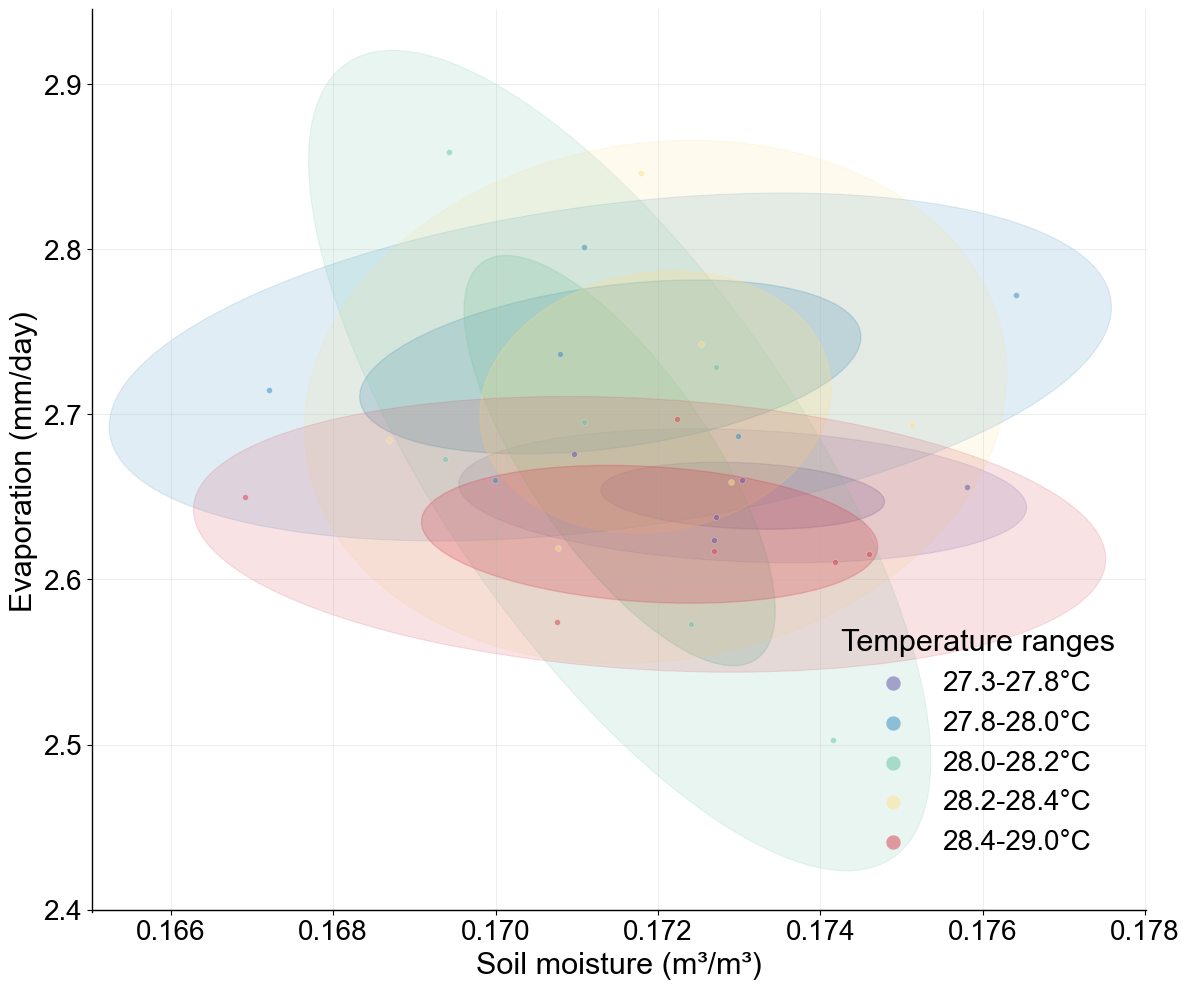


✅ Nature paper quality plot saved as 'SM_evaporation_combined_temperature_JJA_nature_seasonal_mean.png'


In [26]:
# Climate Conditional Plot - Single Plot with Multiple Temperature Bins
# Shows how Soil Moisture - Evaporation relationship changes with increasing temperature
# Modified for JJA season with 1σ and 2σ confidence ellipses
# Uses temperature_thresholds stratification method - All bins in one plot
# Nature paper quality with distinguished colors
# MODIFIED: Added seasonal mean aggregation and consistent 23.5-35°N latitude bands
# MODIFIED: Simplified legend to show only temperature ranges
# To change the region, change    # Step 1.5: Filter for Northern Subtropics (23.5°N to 35°N)
   # print("Step 1.5: Filtering for Northern Subtropics (23.5°N to 35°N)...")
   # lat_min, lat_max = 35.0, 60.0

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

# Set professional climate science style for Nature paper
plt.rcParams.update({
    'font.family': 'Arial',
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'figure.titlesize': 12,
    'lines.linewidth': 1.2,
    'axes.linewidth': 1.0,
})

def add_confidence_ellipse(ax, x, y, color, alpha=0.2, n_std=1.0, linewidth=0.8):
    """Add confidence ellipse around data points using eigenvalue decomposition
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to add ellipse to
    x, y : array-like
        Data points
    color : color specification
        Color for the ellipse
    alpha : float
        Transparency of ellipse
    n_std : float
        Number of standard deviations (1.0 for 1σ, 2.0 for 2σ, etc.)
    linewidth : float
        Width of ellipse border
    """
    if len(x) < 3:
        return None
    
    # Calculate covariance matrix
    cov = np.cov(x, y)
    
    # Get eigenvalues and eigenvectors
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    
    # Calculate ellipse parameters
    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    width = 2 * n_std * np.sqrt(eigenvals[0])
    height = 2 * n_std * np.sqrt(eigenvals[1])
    
    # Create ellipse
    ellipse = patches.Ellipse(xy=(np.mean(x), np.mean(y)),
                              width=width, height=height,
                              angle=angle, alpha=alpha,
                              facecolor=color, edgecolor=color,
                              linewidth=linewidth)
    ax.add_patch(ellipse)
    return ellipse

def create_temperature_stratification(df, n_bins=5, method='temperature_thresholds'):
    """
    Create temperature bins for conditional analysis during Northern Subtropics JJA season
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with temperature data
    n_bins : int
        Number of temperature bins
    method : str
        'quantile', 'equal_width', or 'temperature_thresholds'
        
    Returns:
    --------
    df : pandas.DataFrame with 'temp_bin' column added
    temperature_bins : dict mapping bin_id to (low_temp, high_temp) tuple
    """
    
    if method == 'quantile':
        df['temp_bin'] = pd.qcut(df['temperature'], n_bins, labels=False, duplicates='drop')
        bin_edges = pd.qcut(df['temperature'], n_bins, retbins=True, duplicates='drop')[1]
    elif method == 'equal_width':
        df['temp_bin'] = pd.cut(df['temperature'], n_bins, labels=False)
        bin_edges = pd.cut(df['temperature'], n_bins, retbins=True)[1]
    elif method == 'temperature_thresholds':
        # Northern Subtropics JJA-specific temperature thresholds
        temp_percentiles = np.percentile(df['temperature'], [20, 40, 60, 80])
        bin_edges = np.concatenate([[df['temperature'].min()], 
                                  temp_percentiles, 
                                  [df['temperature'].max()]])
        df['temp_bin'] = pd.cut(df['temperature'], bin_edges, labels=False)
    
    # Get actual number of bins created
    actual_n_bins = df['temp_bin'].nunique()
    
    temperature_bins = {
        i: (bin_edges[i], bin_edges[i+1]) 
        for i in range(actual_n_bins)
    }
    
    print("\nNorthern Subtropics JJA Temperature stratification:")
    for i, (low, high) in temperature_bins.items():
        n_obs = (df['temp_bin'] == i).sum()
        # Add interpretation labels for Northern Subtropics JJA temperatures
        if high < np.percentile(df['temperature'], 25):
            label = "Cool Northern Subtropics JJA"
        elif low > np.percentile(df['temperature'], 75):
            label = "Hot Northern Subtropics JJA"
        else:
            label = "Moderate Northern Subtropics JJA"
        print(f"Bin {i}: {low:.2f}°C to {high:.2f}°C ({label}, {n_obs} observations)")
    
    return df, temperature_bins

def get_nature_colors(n_bins):
    """
    Get distinguished colors suitable for Nature paper
    Returns colors that are visually distinct and colorblind-friendly
    Progressive color scheme from cool to hot temperatures
    """
    if n_bins == 5:
        # Alternative option 2 - Purple to red spectrum
        colors = [
            '#5E4FA2',  # Cool: Purple
            '#3288BD',  # Cool-Moderate: Blue
            '#66C2A5',  # Moderate: Teal
            '#FEE08B',  # Moderate-Hot: Yellow
            '#D53E4F',  # Hot: Red
        ]
        
    elif n_bins == 4:
        colors = [
            '#3288BD',  # Cool: Ocean blue
            '#66C2A5',  # Moderate-Cool: Teal
            '#FDAE61',  # Moderate-Hot: Orange
            '#D53E4F',  # Hot: Crimson red
        ]
        
    elif n_bins == 3:
        colors = [
            '#3288BD',  # Cool: Ocean blue
            '#ABDDA4',  # Moderate: Light green
            '#D53E4F',  # Hot: Crimson red
        ]
        
    else:
        # Fallback to colormap for other bin numbers
        colors = plt.cm.Spectral_r(np.linspace(0.15, 0.85, n_bins))
    
    return colors

def create_combined_temperature_plot(dataset, n_temp_bins=5, stratification_method='temperature_thresholds',
                                    temp_var='tas', evaporation_var='hfls', sm_var='mrsos',
                                    season='JJA', figsize=(12, 10),
                                    add_ellipse=True, ellipse_alpha_outer=0.15, ellipse_alpha_inner=0.25):
    """
    Create single plot showing how SM-E relationship changes across temperature range
    All temperature bins overlaid with different colors
    Focused on Northern Subtropics (23.5°N to 35°N)
    Shows 1σ (68%) and 2σ (95.4%) confidence ellipses
    Nature paper quality with distinguished colors
    **MODIFIED: Uses seasonal mean aggregation**
    **MODIFIED: Simplified legend to show only temperature ranges**
    
    Parameters:
    -----------
    dataset : xarray.Dataset
        Climate data containing soil moisture, evaporation, and temperature
    n_temp_bins : int
        Number of temperature bins to create (default: 5)
    stratification_method : str
        Temperature binning method: 'quantile', 'equal_width', or 'temperature_thresholds'
    temp_var : str
        Temperature variable name in dataset
    evaporation_var : str  
        Evaporation variable name in dataset
    sm_var : str
        Soil moisture variable name in dataset
    season : str
        Season to analyze ('JJA', 'DJF', 'MAM', 'SON')
    figsize : tuple
        Figure size (width, height)
    add_ellipse : bool
        Whether to add confidence ellipse around data points
    ellipse_alpha_outer : float
        Transparency of outer (2σ) confidence ellipse
    ellipse_alpha_inner : float
        Transparency of inner (1σ) confidence ellipse
        
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    
    print(f"Creating combined temperature plot for Northern Subtropics (23.5°N-35°N)")
    print(f"Season: {season}, Temperature bins: {n_temp_bins}")
    print(f"Stratification method: {stratification_method}")
    print(f"Confidence ellipses: 1σ (68%) and 2σ (95.4%)")
    print(f"Using Nature paper quality distinguished colors")
    print(f"**USING SEASONAL MEAN AGGREGATION**")
    
    # Step 1: Extract and preprocess data
    print("\nStep 1: Extracting data...")
    
    # Extract variables
    sm = dataset[sm_var]
    temp = dataset[temp_var]
    evaporation = dataset[evaporation_var]
    
    # Step 1.5: Filter for Northern Subtropics (23.5°N to 35°N)
    print("Step 1.5: Filtering for Northern Subtropics (23.5°N to 35°N)...")
    lat_min, lat_max = 23.5, 35.0
    
    if 'lat' in dataset.coords:
        lat_mask = (dataset.lat >= lat_min) & (dataset.lat <= lat_max)
        sm = sm.where(lat_mask, drop=True)
        temp = temp.where(lat_mask, drop=True)
        evaporation = evaporation.where(lat_mask, drop=True)
        print(f"   Latitude range: {sm.lat.min().values:.1f}°N to {sm.lat.max().values:.1f}°N")
    
    # Step 2: Filter for season
    print(f"\nStep 2: Filtering for {season} season...")
    season_months = {'JJA': [6,7,8], 'MAM': [3,4,5], 'SON': [9,10,11], 'DJF': [12,1,2]}
    
    if season in season_months:
        months = season_months[season]
        sm = sm.sel(time=sm.time.dt.month.isin(months))
        temp = temp.sel(time=temp.time.dt.month.isin(months))
        evaporation = evaporation.sel(time=evaporation.time.dt.month.isin(months))
        print(f"   Selected {len(sm.time)} time points")
    
    # Step 3: Spatial aggregation (weighted by latitude)
    print("\nStep 3: Spatial aggregation...")
    weights = np.cos(np.deg2rad(sm.lat))
    weights.name = "weights"
    
    sm_agg = sm.weighted(weights).mean(dim=['lat', 'lon'])
    temp_agg = temp.weighted(weights).mean(dim=['lat', 'lon'])  
    evaporation_agg = evaporation.weighted(weights).mean(dim=['lat', 'lon'])
    
    # Convert temperature from Kelvin to Celsius if needed
    if temp_agg.max() > 100:
        print("Converting temperature from Kelvin to Celsius...")
        temp_agg = temp_agg - 273.15
    
    # Convert evaporation to mm/day
    print("Converting evaporation to mm/day...")
    evaporation_agg = evaporation_agg * 86400 / (2.45e6)
    
    # Convert soil moisture
    print("Converting soil moisture...")
    sm_agg = sm_agg / (1000 * 0.1)
    
    # NEW: Step 3.5: Apply seasonal mean aggregation
    print("\nStep 3.5: Applying seasonal mean aggregation...")
    
    # Create time dataframe for grouping
    time_df = pd.DataFrame({
        'year': sm_agg.time.dt.year.values,
        'month': sm_agg.time.dt.month.values
    })
    
    # Group by year for JJA season and compute seasonal means
    jja_years = []
    sm_seasonal_list = []
    temp_seasonal_list = []
    evaporation_seasonal_list = []
    
    for year in sorted(time_df['year'].unique()):
        year_mask = time_df['year'] == year
        jja_indices = year_mask[year_mask].index
        
        if len(jja_indices) >= 2:  # Need at least 2 months for a proper JJA season
            sm_val = float(sm_agg.isel(time=jja_indices).mean().values)
            temp_val = float(temp_agg.isel(time=jja_indices).mean().values)
            evaporation_val = float(evaporation_agg.isel(time=jja_indices).mean().values)
            
            sm_seasonal_list.append(sm_val)
            temp_seasonal_list.append(temp_val)
            evaporation_seasonal_list.append(evaporation_val)
            jja_years.append(year)
    
    # Create DataFrame with seasonal means
    df = pd.DataFrame({
        'soil_moisture': sm_seasonal_list,
        'temperature': temp_seasonal_list,
        'evaporation': evaporation_seasonal_list,
        'jja_year': jja_years
    }).dropna()
    
    print(f"\nTotal JJA seasons: {len(df):,}")
    print(f"Year range: {df.jja_year.min()} to {df.jja_year.max()}")
    print(f"Temperature range: {df.temperature.min():.1f}°C to {df.temperature.max():.1f}°C")
    print(f"Evaporation range: {df.evaporation.min():.3f} to {df.evaporation.max():.3f} mm/day")
    print(f"Soil moisture range: {df.soil_moisture.min():.3f} to {df.soil_moisture.max():.3f} m³/m³")
    
    # Step 4: Create temperature stratification using specified method
    print(f"\nStep 4: Creating temperature stratification using '{stratification_method}' method...")
    df, temperature_bins = create_temperature_stratification(df, n_bins=n_temp_bins, method=stratification_method)
    
    actual_n_bins = len(temperature_bins)
    
    # Step 5: Create single plot with all temperature bins
    print(f"\nStep 5: Creating combined plot with {actual_n_bins} temperature bins...")
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get distinguished colors for Nature paper
    colors = get_nature_colors(actual_n_bins)
    print(f"   Using {actual_n_bins} distinguished colors for Nature paper quality")
    
    # Plot each temperature bin with different color
    legend_elements = []
    
    for bin_id in range(actual_n_bins):
        # Extract data for this temperature bin
        mask = df['temp_bin'] == bin_id
        sm_data = df.loc[mask, 'soil_moisture'].values
        evaporation_data = df.loc[mask, 'evaporation'].values
        
        # Get temperature bin information
        temp_low, temp_high = temperature_bins[bin_id]
        bin_temp_mean = df.loc[mask, 'temperature'].mean()
        n_points = len(sm_data)
        
        # Determine temperature label
        if temp_high < np.percentile(df['temperature'], 25):
            temp_label = "Cool"
        elif temp_low > np.percentile(df['temperature'], 75):
            temp_label = "Hot"
        else:
            temp_label = "Moderate"
        
        print(f"\n   Bin {bin_id}: {temp_low:.1f}-{temp_high:.1f}°C ({temp_label}), mean = {bin_temp_mean:.1f}°C, n = {n_points}")
        print(f"      Color: {colors[bin_id]}")
        
        if n_points < 3:
            print(f"      Warning: Too few points for bin {bin_id}")
            continue
        
        # Add confidence ellipses - 2σ first (background), then 1σ (foreground)
        if add_ellipse and n_points >= 3:
            # 2σ (95.4% confidence ellipse) - outer, lighter
            add_confidence_ellipse(ax, sm_data, evaporation_data, 
                                 color=colors[bin_id], alpha=ellipse_alpha_outer, n_std=2.0,
                                 linewidth=0.8)
            
            # 1σ (68% confidence ellipse) - inner, darker
            add_confidence_ellipse(ax, sm_data, evaporation_data, 
                                 color=colors[bin_id], alpha=ellipse_alpha_inner, n_std=1.0,
                                 linewidth=1.0)
        
        # MODIFIED: Simplified legend label - only show temperature range
        scatter = ax.scatter(sm_data, evaporation_data, 
                           alpha=0.5, s=18, color=colors[bin_id], 
                           edgecolors='white', linewidths=0.3, zorder=5,
                           label=f'{temp_low:.1f}-{temp_high:.1f}°C')
    
    # Format plot
    ax.set_facecolor('white')
    
    # Position horizontal axis at Y=1.5
    ax.spines['bottom'].set_position(('data', 2.4))
    
    # Add horizontal reference line
    ax.axhline(y=2.4, color='black', linewidth=0.8, linestyle='-', alpha=0.5, zorder=1)
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Labels with larger font for Nature paper
    ax.set_xlabel('Soil moisture (m³/m³)', fontsize=22)
    ax.set_ylabel('Evaporation (mm/day)', fontsize=22)
    
    
    # Create custom legend with temperature bins and confidence ellipses
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    # Temperature bin legend entries
    temp_legend = ax.legend(loc=(0.7, 0.05), frameon=True, fontsize=20, 
                           title='Temperature ranges', title_fontsize=22,
                           framealpha=0, edgecolor='gray', fancybox=False, 
                           markerscale=2.5)
    
    plt.tight_layout()
    
    print("\n✅ Combined temperature plot created successfully!")
    print(f"Shows SM-E relationship across {actual_n_bins} temperature bins from {df.temperature.min():.1f}°C to {df.temperature.max():.1f}°C")
    print(f"Stratification method: {stratification_method}")
    print(f"All temperature bins overlaid with distinguished Nature paper colors")
    print(f"Confidence ellipses: 1σ (inner, darker) and 2σ (outer, lighter)")
    print(f"**USING SEASONAL MEAN AGGREGATION - {len(df)} JJA seasons**")
    
    return fig, ax

# Example usage
if __name__ == "__main__":
    try:
        sm_dataset = xr.open_dataset("/Users/dianindrawati/Documents/CMIP6_datasets/MIROC6/mrsos/MIROC6_mrsos_future585_20212050_seasonal.nc")
        temp_dataset = xr.open_dataset("/Users/dianindrawati/Documents/CMIP6_datasets/MIROC6/tas/MIROC6_tas_future585_20212050_seasonal.nc")
        evaporation_dataset = xr.open_dataset("/Users/dianindrawati/Documents/CMIP6_datasets/MIROC6/hfls/MIROC6_hfls_future585_20212050_seasonal.nc")
        
        dataset = xr.merge([sm_dataset, temp_dataset, evaporation_dataset], compat='override')
        
        print("Dataset loaded successfully!")
        print("Available variables:", list(dataset.data_vars.keys()))
        print("Time range:", dataset.time.min().values, "to", dataset.time.max().values)
        print("Original latitude range:", f"{dataset.lat.min().values:.1f}°N to {dataset.lat.max().values:.1f}°N")
        
        print("\n" + "="*60)
        print("CREATING NATURE PAPER QUALITY TEMPERATURE PLOT FOR JJA")
        print("WITH SEASONAL MEAN AGGREGATION (23.5-35°N)")
        print("="*60)
        
        fig, ax = create_combined_temperature_plot(
            dataset,
            n_temp_bins=5,                              # Number of temperature bins
            stratification_method='temperature_thresholds',  # Use temperature_thresholds method
            temp_var='tas',
            evaporation_var='hfls',
            sm_var='mrsos',
            season='JJA',
            figsize=(12, 10),                           # Single plot size
            add_ellipse=True,
            ellipse_alpha_outer=0.15,                   # 2σ ellipse transparency
            ellipse_alpha_inner=0.25                    # 1σ ellipse transparency
        )
        
        if fig is not None:
            plt.show()
            
            # Save the plot in high resolution for Nature paper
            fig.savefig('SM-E contour.png', 
                       dpi=800, bbox_inches='tight', facecolor='white')
            print("\n✅ Nature paper quality plot saved as 'SM_evaporation_combined_temperature_JJA_nature_seasonal_mean.png'")
            
        else:
            print("❌ Plot creation failed")
            
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# DJF

Dataset loaded successfully!
Available variables: ['time_bnds', 'lat_bnds', 'lon_bnds', 'depth_bnds', 'mrsos', 'tas', 'hfls']
Time range: 2020-12-01T12:00:00.000000000 to 2050-11-30T12:00:00.000000000
Original latitude range: -88.9°N to 88.9°N

CREATING NATURE PAPER QUALITY TEMPERATURE PLOT FOR DJF
WITH SEASONAL MEAN AGGREGATION (23.5-35°N)
DJF = December (previous year) + January + February
Creating combined temperature plot for Northern Subtropics (23.5°N-35°N)
Season: DJF, Temperature bins: 5
Stratification method: temperature_thresholds
Confidence ellipses: 1σ (68%) and 2σ (95.4%)
Using Nature paper quality distinguished colors
**USING SEASONAL MEAN AGGREGATION**
**DJF: December from previous year, JF from current year**

Step 1: Extracting data...
Step 1.5: Filtering for Northern Subtropics (23.5°N to 35°N)...
   Latitude range: -59.5°N to -35.7°N

Step 2: Spatial aggregation...
Converting temperature from Kelvin to Celsius...
Converting evaporation to mm/day...
Converting soil mo

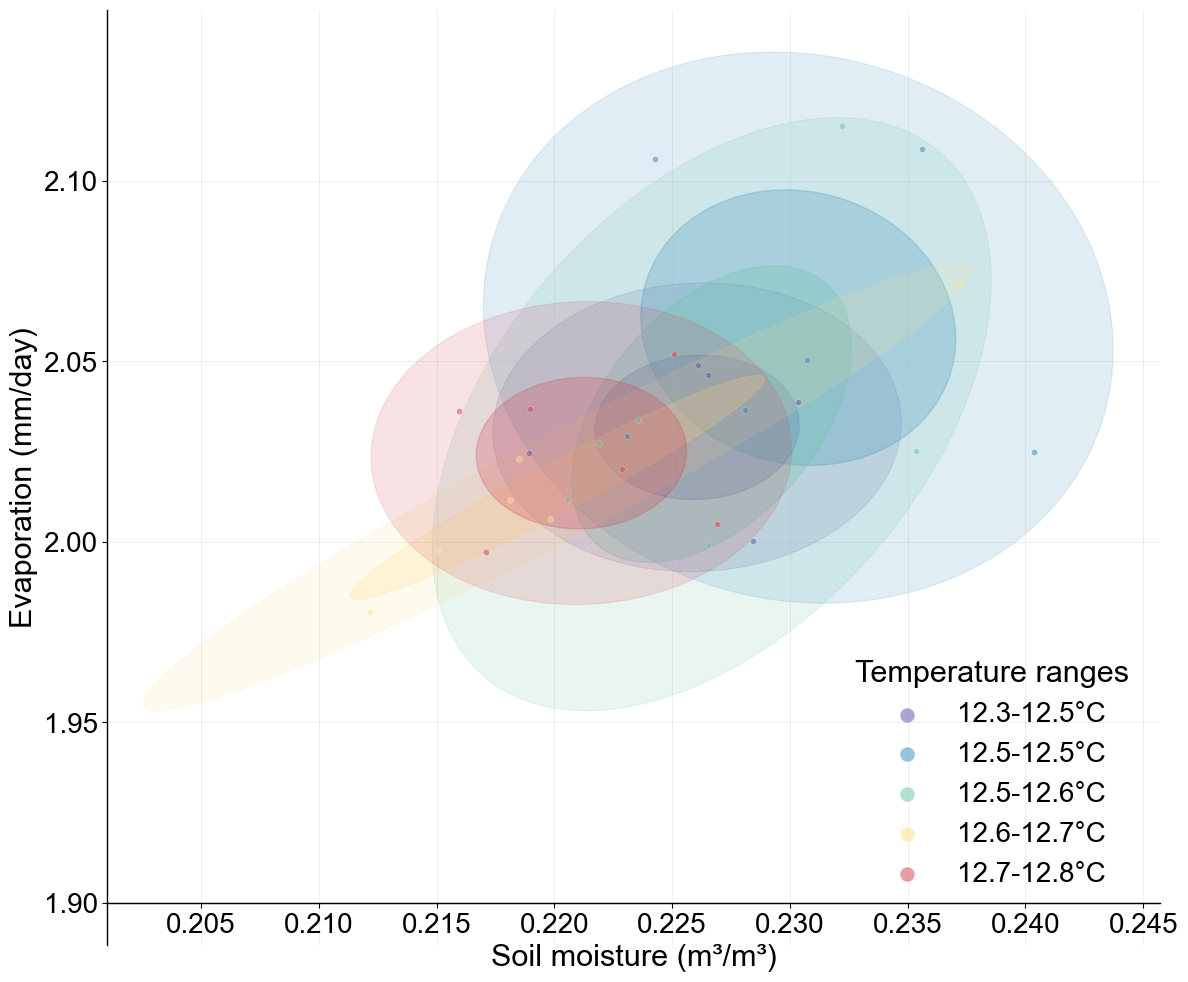


✅ Nature paper quality plot saved as 'SM-E_contour_DJF.png'


In [36]:
# Climate Conditional Plot - Single Plot with Multiple Temperature Bins
# Shows how Soil Moisture - Evaporation relationship changes with increasing temperature
# Modified for DJF season with 1σ and 2σ confidence ellipses
# Uses temperature_thresholds stratification method - All bins in one plot
# Nature paper quality with distinguished colors
# MODIFIED: Added seasonal mean aggregation and consistent 23.5-35°N latitude bands
# MODIFIED: Simplified legend to show only temperature ranges
# MODIFIED: DJF season handling - December from previous year, JF from current year
# To change the region, change    # Step 1.5: Filter for Northern Subtropics (23.5°N to 35°N)
   # print("Step 1.5: Filtering for Northern Subtropics (23.5°N to 35°N)...")
   # lat_min, lat_max = 35.0, 60.0

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

# Set professional climate science style for Nature paper
plt.rcParams.update({
    'font.family': 'Arial',
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'figure.titlesize': 12,
    'lines.linewidth': 1.2,
    'axes.linewidth': 1.0,
})

def add_confidence_ellipse(ax, x, y, color, alpha=0.2, n_std=1.0, linewidth=0.8):
    """Add confidence ellipse around data points using eigenvalue decomposition
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to add ellipse to
    x, y : array-like
        Data points
    color : color specification
        Color for the ellipse
    alpha : float
        Transparency of ellipse
    n_std : float
        Number of standard deviations (1.0 for 1σ, 2.0 for 2σ, etc.)
    linewidth : float
        Width of ellipse border
    """
    if len(x) < 3:
        return None
    
    # Calculate covariance matrix
    cov = np.cov(x, y)
    
    # Get eigenvalues and eigenvectors
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    
    # Calculate ellipse parameters
    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    width = 2 * n_std * np.sqrt(eigenvals[0])
    height = 2 * n_std * np.sqrt(eigenvals[1])
    
    # Create ellipse
    ellipse = patches.Ellipse(xy=(np.mean(x), np.mean(y)),
                              width=width, height=height,
                              angle=angle, alpha=alpha,
                              facecolor=color, edgecolor=color,
                              linewidth=linewidth)
    ax.add_patch(ellipse)
    return ellipse

def create_temperature_stratification(df, n_bins=5, method='temperature_thresholds'):
    """
    Create temperature bins for conditional analysis during Northern Subtropics DJF season
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with temperature data
    n_bins : int
        Number of temperature bins
    method : str
        'quantile', 'equal_width', or 'temperature_thresholds'
        
    Returns:
    --------
    df : pandas.DataFrame with 'temp_bin' column added
    temperature_bins : dict mapping bin_id to (low_temp, high_temp) tuple
    """
    
    if method == 'quantile':
        df['temp_bin'] = pd.qcut(df['temperature'], n_bins, labels=False, duplicates='drop')
        bin_edges = pd.qcut(df['temperature'], n_bins, retbins=True, duplicates='drop')[1]
    elif method == 'equal_width':
        df['temp_bin'] = pd.cut(df['temperature'], n_bins, labels=False)
        bin_edges = pd.cut(df['temperature'], n_bins, retbins=True)[1]
    elif method == 'temperature_thresholds':
        # Northern Subtropics DJF-specific temperature thresholds
        temp_percentiles = np.percentile(df['temperature'], [20, 40, 60, 80])
        bin_edges = np.concatenate([[df['temperature'].min()], 
                                  temp_percentiles, 
                                  [df['temperature'].max()]])
        df['temp_bin'] = pd.cut(df['temperature'], bin_edges, labels=False)
    
    # Get actual number of bins created
    actual_n_bins = df['temp_bin'].nunique()
    
    temperature_bins = {
        i: (bin_edges[i], bin_edges[i+1]) 
        for i in range(actual_n_bins)
    }
    
    print("\nNorthern Subtropics DJF Temperature stratification:")
    for i, (low, high) in temperature_bins.items():
        n_obs = (df['temp_bin'] == i).sum()
        # Add interpretation labels for Northern Subtropics DJF temperatures
        if high < np.percentile(df['temperature'], 25):
            label = "Cool Northern Subtropics DJF"
        elif low > np.percentile(df['temperature'], 75):
            label = "Hot Northern Subtropics DJF"
        else:
            label = "Moderate Northern Subtropics DJF"
        print(f"Bin {i}: {low:.2f}°C to {high:.2f}°C ({label}, {n_obs} observations)")
    
    return df, temperature_bins

def get_nature_colors(n_bins):
    """
    Get distinguished colors suitable for Nature paper
    Returns colors that are visually distinct and colorblind-friendly
    Progressive color scheme from cool to hot temperatures
    """
    if n_bins == 5:
        # Alternative option 2 - Purple to red spectrum
        colors = [
            '#5E4FA2',  # Cool: Purple
            '#3288BD',  # Cool-Moderate: Blue
            '#66C2A5',  # Moderate: Teal
            '#FEE08B',  # Moderate-Hot: Yellow
            '#D53E4F',  # Hot: Red
        ]
        
    elif n_bins == 4:
        colors = [
            '#3288BD',  # Cool: Ocean blue
            '#66C2A5',  # Moderate-Cool: Teal
            '#FDAE61',  # Moderate-Hot: Orange
            '#D53E4F',  # Hot: Crimson red
        ]
        
    elif n_bins == 3:
        colors = [
            '#3288BD',  # Cool: Ocean blue
            '#ABDDA4',  # Moderate: Light green
            '#D53E4F',  # Hot: Crimson red
        ]
        
    else:
        # Fallback to colormap for other bin numbers
        colors = plt.cm.Spectral_r(np.linspace(0.15, 0.85, n_bins))
    
    return colors

def create_combined_temperature_plot(dataset, n_temp_bins=5, stratification_method='temperature_thresholds',
                                    temp_var='tas', evaporation_var='hfls', sm_var='mrsos',
                                    season='DJF', figsize=(12, 10),
                                    add_ellipse=True, ellipse_alpha_outer=0.15, ellipse_alpha_inner=0.25):
    """
    Create single plot showing how SM-E relationship changes across temperature range
    All temperature bins overlaid with different colors
    Focused on Northern Subtropics (23.5°N to 35°N)
    Shows 1σ (68%) and 2σ (95.4%) confidence ellipses
    Nature paper quality with distinguished colors
    **MODIFIED: Uses seasonal mean aggregation**
    **MODIFIED: DJF season - December from previous year, JF from current year**
    **MODIFIED: Simplified legend to show only temperature ranges**
    
    Parameters:
    -----------
    dataset : xarray.Dataset
        Climate data containing soil moisture, evaporation, and temperature
    n_temp_bins : int
        Number of temperature bins to create (default: 5)
    stratification_method : str
        Temperature binning method: 'quantile', 'equal_width', or 'temperature_thresholds'
    temp_var : str
        Temperature variable name in dataset
    evaporation_var : str  
        Evaporation variable name in dataset
    sm_var : str
        Soil moisture variable name in dataset
    season : str
        Season to analyze ('JJA', 'DJF', 'MAM', 'SON')
    figsize : tuple
        Figure size (width, height)
    add_ellipse : bool
        Whether to add confidence ellipse around data points
    ellipse_alpha_outer : float
        Transparency of outer (2σ) confidence ellipse
    ellipse_alpha_inner : float
        Transparency of inner (1σ) confidence ellipse
        
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    
    print(f"Creating combined temperature plot for Northern Subtropics (23.5°N-35°N)")
    print(f"Season: {season}, Temperature bins: {n_temp_bins}")
    print(f"Stratification method: {stratification_method}")
    print(f"Confidence ellipses: 1σ (68%) and 2σ (95.4%)")
    print(f"Using Nature paper quality distinguished colors")
    print(f"**USING SEASONAL MEAN AGGREGATION**")
    print(f"**DJF: December from previous year, JF from current year**")
    
    # Step 1: Extract and preprocess data
    print("\nStep 1: Extracting data...")
    
    # Extract variables
    sm = dataset[sm_var]
    temp = dataset[temp_var]
    evaporation = dataset[evaporation_var]
    
    # Step 1.5: Filter for Northern Subtropics (23.5°N to 35°N)
    print("Step 1.5: Filtering for Northern Subtropics (23.5°N to 35°N)...")
    lat_min, lat_max = -60.0, -35.0
    
    if 'lat' in dataset.coords:
        lat_mask = (dataset.lat >= lat_min) & (dataset.lat <= lat_max)
        sm = sm.where(lat_mask, drop=True)
        temp = temp.where(lat_mask, drop=True)
        evaporation = evaporation.where(lat_mask, drop=True)
        print(f"   Latitude range: {sm.lat.min().values:.1f}°N to {sm.lat.max().values:.1f}°N")
    
    # Step 2: Spatial aggregation (weighted by latitude) BEFORE seasonal filtering
    print("\nStep 2: Spatial aggregation...")
    weights = np.cos(np.deg2rad(sm.lat))
    weights.name = "weights"
    
    sm_agg = sm.weighted(weights).mean(dim=['lat', 'lon'])
    temp_agg = temp.weighted(weights).mean(dim=['lat', 'lon'])  
    evaporation_agg = evaporation.weighted(weights).mean(dim=['lat', 'lon'])
    
    # Convert temperature from Kelvin to Celsius if needed
    if temp_agg.max() > 100:
        print("Converting temperature from Kelvin to Celsius...")
        temp_agg = temp_agg - 273.15
    
    # Convert evaporation to mm/day
    print("Converting evaporation to mm/day...")
    evaporation_agg = evaporation_agg * 86400 / (2.45e6)
    
    # Convert soil moisture
    print("Converting soil moisture...")
    sm_agg = sm_agg / (1000 * 0.1)
    
    # Step 3: DJF seasonal mean aggregation
    print("\nStep 3: Applying DJF seasonal mean aggregation...")
    print("   DJF = December (year-1) + January + February (year)")
    
    # Create time dataframe
    time_df = pd.DataFrame({
        'year': sm_agg.time.dt.year.values,
        'month': sm_agg.time.dt.month.values,
        'time_index': range(len(sm_agg.time))
    })
    
    # Group by DJF winter season (December of previous year + JF of current year)
    djf_years = []
    sm_seasonal_list = []
    temp_seasonal_list = []
    evaporation_seasonal_list = []
    
    for year in sorted(time_df['year'].unique()):
        # Get December from previous year
        dec_prev = time_df[(time_df['year'] == year - 1) & (time_df['month'] == 12)]
        # Get January and February from current year
        jan_feb = time_df[(time_df['year'] == year) & (time_df['month'].isin([1, 2]))]
        
        # Combine indices
        djf_indices = list(dec_prev['time_index']) + list(jan_feb['time_index'])
        
        if len(djf_indices) >= 2:  # Need at least 2 months for a proper DJF season
            sm_val = float(sm_agg.isel(time=djf_indices).mean().values)
            temp_val = float(temp_agg.isel(time=djf_indices).mean().values)
            evaporation_val = float(evaporation_agg.isel(time=djf_indices).mean().values)
            
            sm_seasonal_list.append(sm_val)
            temp_seasonal_list.append(temp_val)
            evaporation_seasonal_list.append(evaporation_val)
            djf_years.append(year)
    
    # Create DataFrame with seasonal means
    df = pd.DataFrame({
        'soil_moisture': sm_seasonal_list,
        'temperature': temp_seasonal_list,
        'evaporation': evaporation_seasonal_list,
        'djf_year': djf_years
    }).dropna()
    
    print(f"\nTotal DJF seasons: {len(df):,}")
    print(f"Year range: {df.djf_year.min()} to {df.djf_year.max()}")
    print(f"Temperature range: {df.temperature.min():.1f}°C to {df.temperature.max():.1f}°C")
    print(f"Evaporation range: {df.evaporation.min():.3f} to {df.evaporation.max():.3f} mm/day")
    print(f"Soil moisture range: {df.soil_moisture.min():.3f} to {df.soil_moisture.max():.3f} m³/m³")
    
    # Step 4: Create temperature stratification using specified method
    print(f"\nStep 4: Creating temperature stratification using '{stratification_method}' method...")
    df, temperature_bins = create_temperature_stratification(df, n_bins=n_temp_bins, method=stratification_method)
    
    actual_n_bins = len(temperature_bins)
    
    # Step 5: Create single plot with all temperature bins
    print(f"\nStep 5: Creating combined plot with {actual_n_bins} temperature bins...")
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get distinguished colors for Nature paper
    colors = get_nature_colors(actual_n_bins)
    print(f"   Using {actual_n_bins} distinguished colors for Nature paper quality")
    
    # Plot each temperature bin with different color
    legend_elements = []
    
    for bin_id in range(actual_n_bins):
        # Extract data for this temperature bin
        mask = df['temp_bin'] == bin_id
        sm_data = df.loc[mask, 'soil_moisture'].values
        evaporation_data = df.loc[mask, 'evaporation'].values
        
        # Get temperature bin information
        temp_low, temp_high = temperature_bins[bin_id]
        bin_temp_mean = df.loc[mask, 'temperature'].mean()
        n_points = len(sm_data)
        
        # Determine temperature label
        if temp_high < np.percentile(df['temperature'], 25):
            temp_label = "Cool"
        elif temp_low > np.percentile(df['temperature'], 75):
            temp_label = "Hot"
        else:
            temp_label = "Moderate"
        
        print(f"\n   Bin {bin_id}: {temp_low:.1f}-{temp_high:.1f}°C ({temp_label}), mean = {bin_temp_mean:.1f}°C, n = {n_points}")
        print(f"      Color: {colors[bin_id]}")
        
        if n_points < 3:
            print(f"      Warning: Too few points for bin {bin_id}")
            continue
        
        # Add confidence ellipses - 2σ first (background), then 1σ (foreground)
        if add_ellipse and n_points >= 3:
            # 2σ (95.4% confidence ellipse) - outer, lighter
            add_confidence_ellipse(ax, sm_data, evaporation_data, 
                                 color=colors[bin_id], alpha=ellipse_alpha_outer, n_std=2.0,
                                 linewidth=0.8)
            
            # 1σ (68% confidence ellipse) - inner, darker
            add_confidence_ellipse(ax, sm_data, evaporation_data, 
                                 color=colors[bin_id], alpha=ellipse_alpha_inner, n_std=1.0,
                                 linewidth=1.0)
        
        # MODIFIED: Simplified legend label - only show temperature range
        scatter = ax.scatter(sm_data, evaporation_data, 
                           alpha=0.5, s=18, color=colors[bin_id], 
                           edgecolors='white', linewidths=0.3, zorder=5,
                           label=f'{temp_low:.1f}-{temp_high:.1f}°C')
    
    # Format plot
    ax.set_facecolor('white')
    
    # Position horizontal axis at Y=1.5
    ax.spines['bottom'].set_position(('data', 1.9))
    
    # Add horizontal reference line
    ax.axhline(y=1.9, color='black', linewidth=0.8, linestyle='-', alpha=0.5, zorder=1)
    
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Labels with larger font for Nature paper
    ax.set_xlabel('Soil moisture (m³/m³)', fontsize=22)
    ax.set_ylabel('Evaporation (mm/day)', fontsize=22)
    
    
    # Create custom legend with temperature bins and confidence ellipses
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    # Temperature bin legend entries
    temp_legend = ax.legend(loc=(0.7, 0.05), frameon=True, fontsize=20, 
                           title='Temperature ranges', title_fontsize=22,
                           framealpha=0, edgecolor='gray', fancybox=False, 
                           markerscale=2.5)
    
    plt.tight_layout()
    
    print("\n✅ Combined temperature plot created successfully!")
    print(f"Shows SM-E relationship across {actual_n_bins} temperature bins from {df.temperature.min():.1f}°C to {df.temperature.max():.1f}°C")
    print(f"Stratification method: {stratification_method}")
    print(f"All temperature bins overlaid with distinguished Nature paper colors")
    print(f"Confidence ellipses: 1σ (inner, darker) and 2σ (outer, lighter)")
    print(f"**USING SEASONAL MEAN AGGREGATION - {len(df)} DJF seasons**")
    print(f"**DJF: December from previous year + JF from current year**")
    
    return fig, ax

# Example usage
if __name__ == "__main__":
    try:
        sm_dataset = xr.open_dataset("/Users/dianindrawati/Documents/CMIP6_datasets/MIROC6/mrsos/MIROC6_mrsos_future585_20212050_seasonal.nc")
        temp_dataset = xr.open_dataset("/Users/dianindrawati/Documents/CMIP6_datasets/MIROC6/tas/MIROC6_tas_future585_20212050_seasonal.nc")
        evaporation_dataset = xr.open_dataset("/Users/dianindrawati/Documents/CMIP6_datasets/MIROC6/hfls/MIROC6_hfls_future585_20212050_seasonal.nc")
        
        dataset = xr.merge([sm_dataset, temp_dataset, evaporation_dataset], compat='override')
        
        print("Dataset loaded successfully!")
        print("Available variables:", list(dataset.data_vars.keys()))
        print("Time range:", dataset.time.min().values, "to", dataset.time.max().values)
        print("Original latitude range:", f"{dataset.lat.min().values:.1f}°N to {dataset.lat.max().values:.1f}°N")
        
        print("\n" + "="*60)
        print("CREATING NATURE PAPER QUALITY TEMPERATURE PLOT FOR DJF")
        print("WITH SEASONAL MEAN AGGREGATION (23.5-35°N)")
        print("DJF = December (previous year) + January + February")
        print("="*60)
        
        fig, ax = create_combined_temperature_plot(
            dataset,
            n_temp_bins=5,                              # Number of temperature bins
            stratification_method='temperature_thresholds',  # Use temperature_thresholds method
            temp_var='tas',
            evaporation_var='hfls',
            sm_var='mrsos',
            season='DJF',
            figsize=(12, 10),                           # Single plot size
            add_ellipse=True,
            ellipse_alpha_outer=0.15,                   # 2σ ellipse transparency
            ellipse_alpha_inner=0.25                    # 1σ ellipse transparency
        )
        
        if fig is not None:
            plt.show()
            
            # Save the plot in high resolution for Nature paper
            fig.savefig('SM-E_contour_DJF.png', 
                       dpi=800, bbox_inches='tight', facecolor='white')
            print("\n✅ Nature paper quality plot saved as 'SM-E_contour_DJF.png'")
            
        else:
            print("❌ Plot creation failed")
            
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()